In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import lil_matrix

# Topic: LLM for Recommendation Systems
---

Version: Aug 2025 Written by Jin Yuze (jin.yuze@u.nus.edu)

###################

Under Construction

TODO:
- Go through the notebook and make the explanations more suitable
- Prof's feedback:
    - In the graph-awareness attention part, need better explain
    - There are some formula about attention, not included in the notebook, need to add them
    - Pre-training and Fine-tuning, want some graph: model architecture, and possibly input/output at each layer?

###################

---
## Introduction

In this topic, we want to explore the cutting edge of using Large Language Models (LLMs) for recommendation systems. LLMs have shown great potential in understanding and generating human-like text, and they can be leveraged to enhance the recommendation process by providing more personalized and context-aware suggestions.

In recent years, there has been a surge of interest in using LLMs for recommendation systems. These models can analyze user preferences, item descriptions, and contextual information to generate recommendations that are more aligned with user interests. The models can take the textual data associated with items (such as product descriptions, reviews, and user-generated content) and use it to better understand the relationships between users and items, leading to more accurate and relevant recommendations, compare to conventional collaborative filtering or content-based methods.

In this topic, we will explore this area following a reseach paper that proposes a noval approach.

[LLM-Enhanced User-Item Interactions: Leveraging Edge Information for Optimized Recommendations](https://arxiv.org/abs/2402.09617)

[Code Repo](https://github.com/anord-wang/LLM4REC)

#### Prelude

We assume you already have some basic knowledges on: 

- Conventional recommendation systems, such as collaborative filtering and content-based filtering, which are the already covered content in this course.

- Basic knowledge of Large Language Models (LLMs), such as Natural Language Processing (NLP) tasks, and how LLMs can be used to process and generate text, Attention Mechanism, Transformers, etc. (We have covered these basics in the course as well).

- Basic knowledge of PyTorch, such as how to define a model, how to train a model, and how to use PyTorch's built-in functions for optimization and loss calculation. (These are covered in some basic ML courses, if you are not familiar with PyTorch, please at least get some basic understanding of Python.)

#### Example Code
Since LLM is a complex topic, the code repo is hard to be simplified into a single notebook, thus we will not cover the complete code in this notebook. We are just going through some key components and concepts to help you understand the overall architecture. 

The full version of the code repo is provided as additional materials, which you are recommanded to try out by yourself.
We have provided a detailed instruction on how to run the code, and we provide the checkpoints for you to test the code without training the model from scratch (which will take some GPU resouces and long time).
And in the code repo, we provide detailed comments on each component, and a more technical explanation of the model architecture and training process.

---
## Overview

It is not trivial to use LLMs for recommendation systems, as the two systems have different assumptions on data structure. 

The paper we are going to explore proposes a novel approach that tries to fill in the gap between graph-based user & item interactions and LLMs' text-based understanding.

In previous studies, we have seen the conventional recommendation methods, such as collaborative filtering and content-based filtering, which are based on user-item interactions. 
These methods typically rely on the assumption that user-item interactions can be represented as a `bipartite graph`, where users and items are nodes, and interactions (such as ratings or clicks) are edges. 

<img src="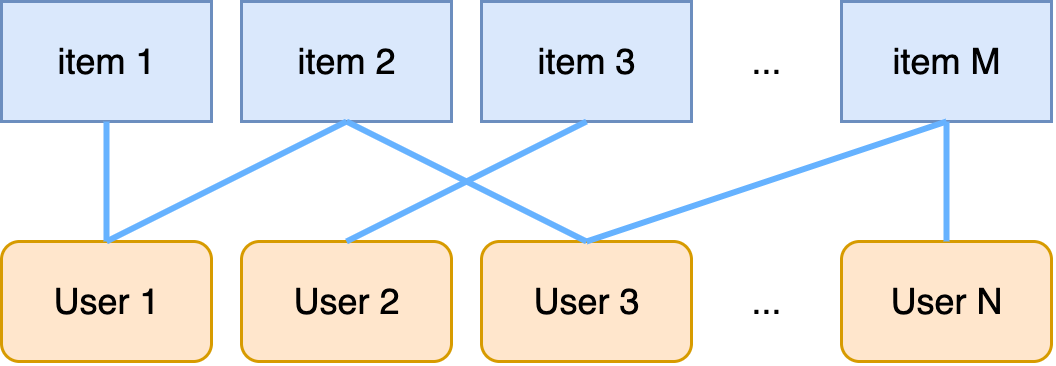
" width="400">

(An example of the bipartite graph, where the nodes are users and items, and the edges represent interactions.)

We have seen how graph neural networks (GNNs) can be used to model these interactions, allowing for the aggregation of information from neighboring nodes to improve recommendations. 
These methods are shown to be effective in capturing the relationships between users and items.

While you have seen how LLMs can be used for various NLP tasks, such as text generation, sentiment analysis, and question answering, they are typically trained on large text corpora and are not directly designed to handle graph-based data. 
LLMs excel at understanding and generating text, but they do not inherently understand the structure of user-item interactions as a graph.

Thus how to bridge the gap between these two paradigms is a key challenge in using LLMs for recommendation systems.

---
### Idea

In this example code, we will explore one solution to this challenge.

The idea of this example paper is to leverage the edge information in user-item interactions to enhance the recommendations generated by LLMs.
The authors propose a novel approach that combines the strengths of both graph-based methods and LLMs, allowing for more effective recommendations:

- **Graph-aware Attention Mechanism** – The authors modify the LLM’s attention module by incorporating additional bias terms derived from the graph structure of the user-item interactions. This includes both direct connections (user-item links) and indirect relationships (shortest paths in the interaction graph). By integrating these structural signals into the attention computation, the model can focus more on semantically or structurally related nodes, rather than relying purely on sequential token relationships.

- **Tokenizer and Embedding Modifications** – To handle user and item IDs without losing their semantic identity, the authors adjust the tokenizer so that these IDs are treated as indivisible tokens. Special embeddings are then assigned to these tokens, enabling the LLM to recognize and represent specific users and items consistently during training and inference.

- **Prompt Design** – The input to the LLM is carefully constructed to include textual descriptions, user profiles, and the graph-based interaction information. This design ensures the model receives both semantic content and structural context, improving its ability to generate relevant recommendations.

- **Two-stage Training Strategy** – The training process consists of a pretraining stage, where the model learns general patterns from the full user-item corpus using a text generation objective, and a fine-tuning stage, where the model is optimized for the recommendation task by predicting the most likely items for a given user prompt.

### Terminology and Problem Statement:

In our description, we will follow the paper's terminology and problem statement, which we copy from the paper: 

> Consider the existence of `I` users and `J` items, let `X`<sub>`ij`</sub> be the binary interaction (e.g., purchase) matrix between user `i` and item `j`. 
> Besides, we collect user descriptions, item descriptions (e.g., prices, brand, category, title), user reviews for items, and explanations of user purchase reasons.
> We denote `T`<sub>`i`</sub> as the descriptions of the user `i`, `T`<sub>`j`</sub> as the descriptions of the item `j`, `T`<sub>`ij`</sub> as the joint texts of the user `i` and item `j`, such as user reviews and purchase reasons for items. 
> We unify all textual descriptions into `T` that includes `N` sequences, `k` indexes the tokens in each sequence, and `T`<sub>`nk`</sub> is the `𝑘`-th token in the `n`-th sequence. 
> Our goal is to leverage LLMs and graphs to develop a generative recommender system that takes a prompt, including a user ID and a user’s historical interaction records with items, and generates product recommendations to the user.

---

### Step-1 Attention may not be enough

Let's start from looking at our data. In our data, we have the following information:
- User's profile, Item's description, User's reviews. These are textual data. LLM can learn from these data to understand the user's preferences and item characteristics.
- User-item interactions, and second-order relationships between items. These are graph-based data. We can use these data to enhance the LLM's understanding of the relationships between users and items.

For the textual data, it is straightforward to use LLMs to process them. We can simply feed the text into the LLM and let it generate embeddings or predictions based on the text.

For the graph-based data, we need to do some extra work to enable the LLM to process them.

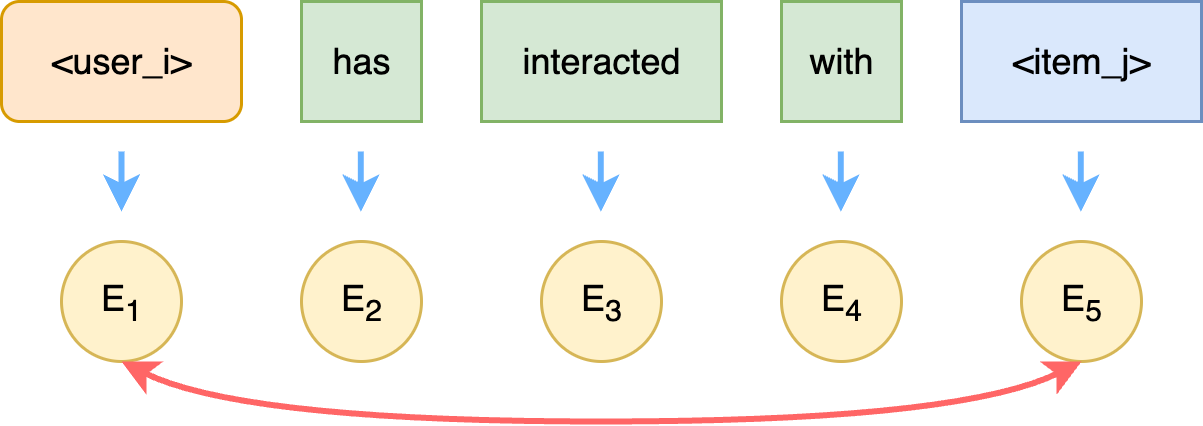

Previous, Attention mechanism is the key component to capture the relationships between tokens in the **text**. However, when we provide information like: 
```
<user_i> has interaction with <item_j>
```
The attention mechanism can only provide the "language" relationship between the tokens `<user_i>` and `<item_j>`, while the actual graph-based relationship is missing, thus the model may not fully understand the relationship between the user and the item.

To address this, we need to modify the attention mechanism to incorporate the graph-based relationships.

The original attention is defined as: 
<math display="block">
<mi>A</mi><mi>t</mi><mi>t</mi><mo stretchy="false">(</mo><mi>Q</mi><mo>,</mo><mi>K</mi><mo>,</mo><mi>V</mi><mo stretchy="false">)</mo><mo>=</mo><mi>S</mi><mi>o</mi><mi>f</mi><mi>t</mi><mi>m</mi><mi>a</mi><mi>x</mi><mo stretchy="false">(</mo><mfrac><mrow><mi>Q</mi><msup><mi>K</mi><mi>T</mi></msup></mrow><msqrt><msub><mi>d</mi><mi>k</mi></msub></msqrt></mfrac><mo stretchy="false">)</mo><mi>V</mi>
</math>
(We will omit the detailed explanation of the attention mechanism here.) As you can see, the attention is only defined based on the textural relationship between the tokens.

Thus, in the example paper, the Attention between `user` or `item` is modified to: 
<math display="block">
<mi>A</mi><mi>t</mi><msup><mi>t</mi><mo>′</mo></msup><mo stretchy="false">(</mo><mi>Q</mi><mo>,</mo><mi>K</mi><mo>,</mo><mi>V</mi><mo stretchy="false">)</mo><mo>=</mo><mi>S</mi><mi>o</mi><mi>f</mi><mi>t</mi><mi>m</mi><mi>a</mi><mi>x</mi><mo stretchy="false">(</mo><mfrac><mrow><mi>Q</mi><msup><mi>K</mi><mi>T</mi></msup></mrow><msqrt><msub><mi>d</mi><mi>k</mi></msub></msqrt></mfrac><mo>+</mo><mi>R</mi><mo stretchy="false">)</mo><mi>V</mi>
</math>

with an additional bias term `R` that is defined as: 
<math display="block">
<mi>R</mi><mo>=</mo><msup><mi>R</mi><mrow><mi>c</mi><mi>o</mi><mi>n</mi><mi>n</mi></mrow></msup><mo>+</mo><msup><mi>R</mi><mrow><mi>p</mi><mi>a</mi><mi>t</mi><mi>h</mi></mrow></msup>
</math>
where `R`<sub>`con`</sub> is the direct connection between the user and item, and `R`<sub>`path`</sub> is the second-order relationship between items.

For the direct connection, it represents the strong direct interaction between the user and the item. It is easily defined as: 
<math display="block"><msubsup><mi>R</mi><mrow><mi>i</mi><mi>j</mi></mrow><mrow><mrow><mi mathvariant="normal">c</mi><mi mathvariant="normal">o</mi><mi mathvariant="normal">n</mi><mi mathvariant="normal">n</mi></mrow></mrow></msubsup><mo>=</mo><mrow data-mjx-texclass="INNER"><mo data-mjx-texclass="OPEN">{</mo><mtable columnalign="left left" columnspacing="1em" rowspacing=".2em"><mtr><mtd><mn>1</mn><mo>,</mo></mtd><mtd><mrow><mtext>if there is a direct connection between node&nbsp;</mtext><mrow><mi>i</mi></mrow><mtext>&nbsp;and&nbsp;</mtext><mrow><mi>j</mi></mrow><mtext>,</mtext></mrow></mtd></mtr><mtr><mtd><mn>0</mn><mo>,</mo></mtd><mtd><mtext>otherwise.</mtext></mtd></mtr></mtable><mo data-mjx-texclass="CLOSE" fence="true" stretchy="true" symmetric="true"></mo></mrow></math>

While for the indirect connection, it is corresponding to the "collaborative information" in conventional solutions. It can be modelized as "A normalized shortest path score between nodes, which is computed based on the entire graph." It is defined as:
<math display="block"><msubsup><mi>R</mi><mrow><mi>i</mi><mi>j</mi></mrow><mrow><mi>p</mi><mi>a</mi><mi>t</mi><mi>h</mi></mrow></msubsup><mo>=</mo><mn>1</mn><mo>−</mo><mfrac><mrow><mi>δ</mi><msub><mi>P</mi><mrow><mi>i</mi><mi>j</mi></mrow></msub></mrow><mrow><mi>m</mi><mi>a</mi><mi>x</mi><mo stretchy="false">(</mo><mi>P</mi><mo stretchy="false">)</mo></mrow></mfrac></math>
where `P` is the length of the shortest path between nodes `i` and `j`. and `δ` is a factor between 0 and 1. 

With this modified Attention mechanism, now the model can capture both the textual relationships and the graph-based relationships between users and items.

In [ ]:
# Let's create a simple example graph
# Assume we have a very small bipartite graph with 2 users and 3 items
users = ["<user_0>", "<user_1>"]
items = ["<item_0>", "<item_1>", "<item_2>"]
all_nodes = users + items

# Build the interaction mateix（user-row × item-column）
interaction = lil_matrix((len(users), len(items)))
# Example interactions we added to the graph
interaction[0, 0] = 1  # user_0 <-> item_0
interaction[0, 2] = 1  # user_0 <-> item_2
interaction[1, 1] = 1  # user_1 <-> item_1
interaction[1, 2] = 1  # user_1 <-> item_2

# Now we can create the graph representation
n_users, n_items = interaction.shape
num_nodes = n_users + n_items
graph = lil_matrix((num_nodes, num_nodes))
graph[:n_users, n_users:] = interaction
graph[n_users:, :n_users] = interaction.T

In [16]:
def plot_graph(graph, all_nodes):
    plt.figure(figsize=(4, 4))
    ax = plt.gca()
    ax.set_title("User-Item Interaction")
    pos = {}
    for i, node in enumerate(all_nodes):
        if "user" in node:
            pos[node] = (0, i)
        else:
            pos[node] = (1, i - len(users))
    for i in range(graph.shape[0]):
        for j in range(graph.shape[1]):
            if graph[i, j] > 0:
                plt.plot([pos[all_nodes[i]][0], pos[all_nodes[j]][0]],
                         [pos[all_nodes[i]][1], pos[all_nodes[j]][1]], 'k-', alpha=0.5)
    for node, (x, y) in pos.items():
        plt.text(x, y, node, fontsize=8, ha='center', va='center',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle'))
    plt.axis('off')
    plt.show()

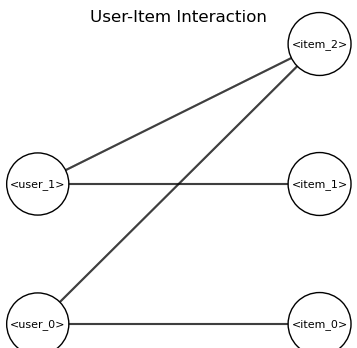

In [17]:
# A bit visualization:
plot_graph(graph, all_nodes)

In [18]:
# Assume now we have a simple sentence that describes an interaction
tokens = ["<user_0>", "has", "interacted", "with", "<item_0>"]
vocab_size = len(tokens)
embed_dim = 16

In [ ]:
# NOTE: The following is a mock embedding metrix for demonstration purposes.
# In practice, this should be trained with LLMs or other embedding techniques.
np.random.seed(42)

token_embeddings = np.random.randn(vocab_size, embed_dim)

# embedding of the user token
token_embeddings[0] = np.ones(embed_dim) # simply assume the embeddding of token "<user_0>" is a vector of all ones

# embedding of the item token
token_embeddings[4] = np.ones(embed_dim) * 0.95 # simply assume the embeddding of token "<item_0>" is a vector of all 0.95

# Becasuse we don't want to make this example too complicated, we are just "pretending" a embedding here. 
# In practice, you should use a pre-trained LLM to get the embeddings of the tokens.

In [ ]:
# In this step, we will compute the graph-based bias, basically the R values.

# R_conn:
# it is actuall the same as the graph.
R_conn = graph.toarray()

# R_path:
# First, need to calculate the shortest path between all nodes in the graph.
dist_matrix = shortest_path(csgraph=graph, directed=False, method='FW')  # distance matrix, shape: (5x5)

SIMILARITY_CAP = 6 # 6 is used in the original code, it can be seen as a hyperparameter.

# In their codebase, there is a heuristic design, that not using the distance matrix directly,
# but transforming it to a "similarity matrix" by subtracting from SIMILARITY_CAP, and then normalizing it.
# They are using this as the R_path matrix, which can achieve a similar effect.
transformed_dist_matrix = SIMILARITY_CAP - dist_matrix 
transformed_dist_matrix = np.maximum(transformed_dist_matrix, 0)
min_val, max_val = np.min(transformed_dist_matrix), np.max(transformed_dist_matrix)
R_path = (transformed_dist_matrix - min_val) / (max_val - min_val + 1e-6)

R_matrix = R_conn + R_path
# A heuristic implementation of the normalization the R_matrix
min_total, max_total = np.min(R_matrix), np.max(R_matrix)
R_matrix = (R_matrix - min_total) / (max_total - min_total + 1e-6)

R_sub = np.zeros((len(tokens), len(tokens))) 
token_indices = [all_nodes.index(t) if t in all_nodes else -1 for t in tokens]
for i, idx_i in enumerate(token_indices):
    for j, idx_j in enumerate(token_indices):
        if idx_i != -1 and idx_j != -1:
            R_sub[i, j] = R_matrix[idx_i, idx_j]
        else:
            R_sub[i, j] = 0  # Don't apply bias if the token is not an ID.

# Now the R_sub matrix contains the R bias to be applied to the attention scores

In [6]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def compute_attention(Q, K, bias=None):
    scores = Q @ K.T
    if bias is not None:
        scores += bias
    weights = softmax(scores, axis=-1)
    return weights

Q = token_embeddings
K = token_embeddings

# Compute attention scores with and without bias
attn_vanilla = compute_attention(Q, K) # The vanilla attention without bias
attn_graph = compute_attention(Q, K, bias=R_sub) # The attention with graph-based bias

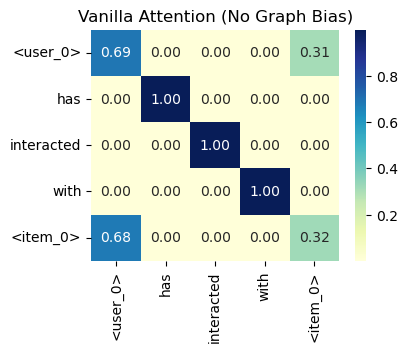

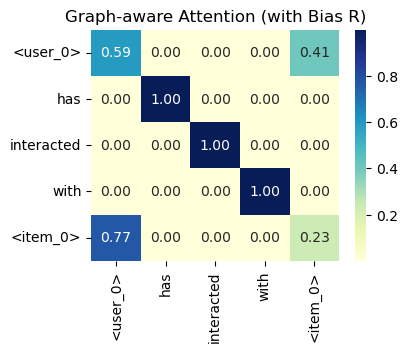

In [7]:
# Visualization of the attention matrices

def plot_attn(matrix, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, xticklabels=tokens, yticklabels=tokens, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(title)
    plt.show()

plot_attn(attn_vanilla, "Vanilla Attention (No Graph Bias)")
plot_attn(attn_graph, "Graph-aware Attention (with Bias R)")

From the above example outputs, you can see that with the modified attention mechanism, the model now adds additional bias between the user and item IDs. Since in our example, the user and item IDs are directly connected. 

**Corresponding Code**:

In the code repo, you can find the implementation of the modified attention mechanism in:
- `data_processing_scripts/data_preprocesing.py` : `create_interaction_matrix` for preparing the `R` matrix
- `libs/modeling_gpt2.py` : `GPT2AttentionWithBC` for the modified attention mechanism 
- Correspondingly, in the `llm4rec_training.py`, `llm4rec_finetuning.py`, and `llm4rec_evaluation.py`, the invocation of the modified attention mechanism is handled.

---

### Step-2 Take care of the Tokenizer

(This part is already shown in previous example codes.)

In LLM4Rec, the tokenizer of the base LLM (e.g. GPT-2) is modified to handle user IDs and item IDs as special whole tokens. 

This is necessary because user/item IDs are not normal words: they are unique identifiers that should not be broken into subwords. 
If we use an unmodified tokenizer on an ID like `user_123`, it would be split into pieces (e.g. `user`, `_`, and `123`). 
Such splitting causes the model to lose the identity of the user or item; the token `user` or `123` alone has no specific meaning for a particular user 123. 

To fix this, LLM4Rec customizes the tokenizer vocabulary so that each user and item ID is treated as an indivisible token. 
In practice, all strings like user_<id> and item_<id> are added as single tokens. 

The model is then given special embeddings for these new tokens. 
This means the LLM will learn a distinct embedding vector for each user and each item, allowing it to recognize specific users/items consistently during training and inference. 
By preserving each ID as one token, we ensure the model can capture the unique semantics of, say, user_123 (distinct from user_456, etc.) instead of seeing them as generic words or numbers. 

Overall, modifying the tokenizer in this way injects the traditional ID-based collaborative filtering signals into the LLM’s vocabulary, bridging the gap between ID-based representations and natural language text.


In [8]:
# If you are running on your own machine, you may need to install the transformers library:
# pip install transformers

from transformers import AutoTokenizer

# This is an example of using the original tokenizer (without special tokens)
default_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# example sentence
text = "<user_1234> has interacted with <item_5678>"

# Print the raw tokenizer output, you would see the default tokenizer would break the IDs into subwords
# which is not what we want in recommendation tasks.
print("Raw tokenizer tokens:")
print(default_tokenizer.tokenize(text))


None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Raw tokenizer tokens:
['<', 'user', '_', '123', '##4', '>', 'has', 'interact', '##ed', 'with', '<', 'item', '_', '56', '##7', '##8', '>']


In [9]:
# NOTE: this pattern match is simple, and if the dataset has a different ID format, 
# you would need to adjust the regex pattern accordingly.

class CustomTokenizer:
    def __init__(self, base_tokenizer, user_ids, item_ids):
        # Remove angle brackets in internal keys for matching
        self.base_tokenizer = base_tokenizer
        self.user_token_encoder = {uid: i for i, uid in enumerate(user_ids)}  # user_1234
        self.item_token_encoder = {iid: i for i, iid in enumerate(item_ids)}  # item_5678

    def _pre_tokenize(self, text):
        '''
            In this function, we break down the sentence that 
            describes user/item features or their historical 
            interactions into pieces, where the ID word like
            <user_i> or <item_j> is kept as a single piece. 
            
            E.g.,
                text = "This is <user_1>'s comment about <item_3> 
                        after he bought the item"
                pieces = ['This is', '<user_1>', "'s comment about", 
                          '<item_3>', ' after he bought the item']
                          
            Note that we keep the space on the left of a word to 
            show that the word does not appear on the beginning 
            part of a sentence.
        '''
        pattern = r'(<user_\d+>|<item_\d+>)'
        pieces = re.split(pattern, text)
        pieces = [p.rstrip() for p in pieces if p.strip()]
        return pieces

    def _tokenize(self, text):
        '''
        When the token is a user/item ID, we keep it as-is;
        otherwise, we apply the base tokenizer.
        '''
        split_tokens = []
        pieces = self._pre_tokenize(text)
        for piece in pieces:
            if piece.startswith("<user_") and piece.endswith(">"):
                uid = piece[1:-1]  # strip angle brackets
                if uid in self.user_token_encoder:
                    split_tokens.append(piece)
                    continue
            elif piece.startswith("<item_") and piece.endswith(">"):
                iid = piece[1:-1]
                if iid in self.item_token_encoder:
                    split_tokens.append(piece)
                    continue
            # Default case: use base tokenizer
            split_tokens += self.base_tokenizer.tokenize(piece)
        return split_tokens


In [10]:
user_ids = ["user_1234"]
item_ids = ["item_5678"]
custom_tokenizer = CustomTokenizer(default_tokenizer, user_ids, item_ids)

print("Customized tokenizer tokens:")
print(custom_tokenizer._tokenize(text))

Customized tokenizer tokens:
['<user_1234>', 'has', 'interact', '##ed', 'with', '<item_5678>']


**Corresponding Code**:

In the code repo, you can find the implementation of the modified tokenizer in:
- `libs/tokenizer.py` : `TokenizerWithUserItemIDTokens` for the modified tokenizer handing.

---
### Step-3&4 Prompt Engineering, Pre-training and Fine-tuning
LLM4Rec uses a two-stage training pipeline: pre-training followed by fine-tuning. These two stages work together to help the language model gradually learn how to make recommendations.

In the pre-training stage, the model is trained on a large number of user-item interaction texts. 
These prompts include user profiles, item descriptions, and interaction histories. 
The goal is to help the model build general knowledge about the users and items.

In the fine-tuning stage, the model is trained on data more specific to recommendation tasks. 
The prompts are shorter and more focused, such as asking what item a user will interact with next. 
The model learns to generate or select the correct item based on the given history.

This section explains how prompts are constructed for both stages, what they look like, and how they guide the model during training.

#### Step 3 - **Prompt Engineering**

The prompt should be carefully designed to allow the model to learn the relationships between users and items effectively.

##### **Information in the data**

The LLM4Rec approach uses rich information from the recommendation dataset. Specifically, the data includes:

- **User/Item Tokens** to encode semantic information about users and items;
- **Item Contents**, describing item attributes such as title, brand, and categories;
- **1st Order User-Item Relationships**, capturing user interactions through reviews and purchase explanations;
- **2nd Order User-Item Relationships**, representing item-level associations;
- **User-Item Interaction Events**, incorporating purchase histories as prompts.

All this information is converted into text form so it can be used to prompt a language model. 
The goal is to have the model read who the user is, what the item is, and how the user interacted with items, all in natural language form.

##### **Pre-Training Prompts**

For the pre-training stage, the authors design a **“crowd contextual prompt”** – essentially a single large prompt that crowds in many types of contextual information about users and items. It is constructed by combining multiple pieces of the dataset into one textual sequence. 

According to the paper, the pre-training prompt is structured as follows:

<img src="data:image/png;base64,
..." width="400">

In summary, the pre-training prompt is “crowded” with contextual info: it tells the model who the user is, details about a particular item, what the user did or said with that item, how items relate, and what else the user has bought. The LLM is trained on these prompts by predicting the continuation of each text, which teaches it the domain context.

**Corresponding Code**:

The textual data is formatted in:
- `data_processing_scripts/data_preprocess_amazon.py`, where the crowd contextual prompts are constructed and saved. 

##### **Fine-Tuning Prompts**

For the fine-tuning stage, the method uses a more **targeted prompt** focusing on a single user’s history, termed the “personalized predictive prompt.” 
Instead of providing all general context, this prompt is tailored to one user and is used to train the model to actually make a recommendation for that user.

The fine-tuning prompt is structured to be:

<img src="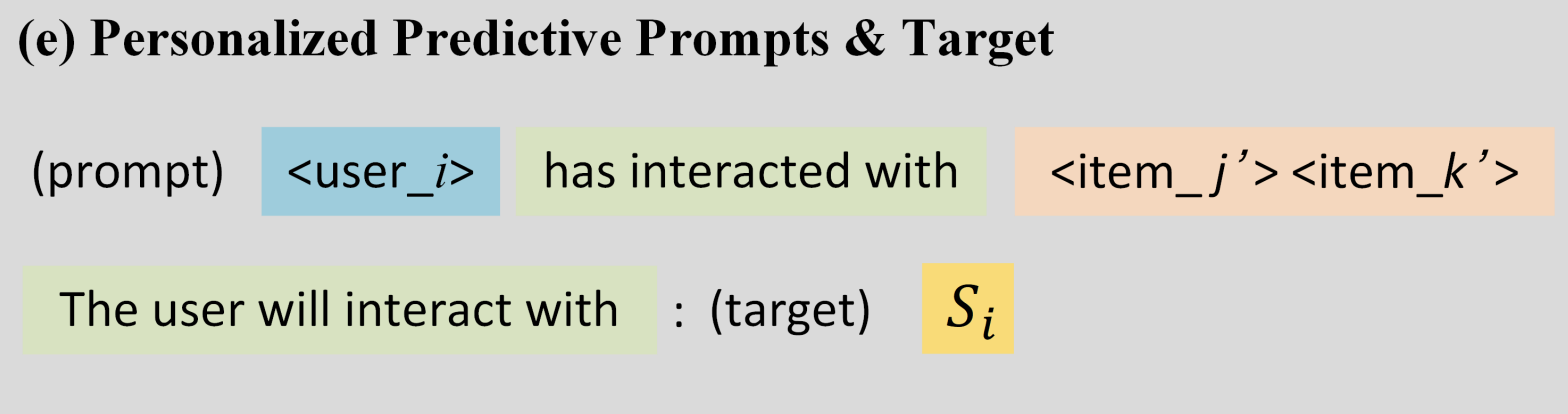
" width="400">


By fine-tuning on these prompts, the model learns to take a given user’s history (the input prompt) and generate a likely next item or list of items that the user would purchase (the output).

**Corresponding Code**:

The fine-tuning prompt is formatted in:
- `libs/data.py` : "RecommendationGPTTrainGeneratorBatch" where the data loader is defined. 

#### Step 4.1 - **Pretraining Stage**

In this stage, the augmented LLM is trained with the crowd contextual prompts. And the optimization objective is to maximize the **token generation likelihood**. The likelihood function is given by:

<math display="block"><msub><mi>L</mi><mrow><mi>p</mi><mi>r</mi><mi>e</mi><mo>−</mo><mi>t</mi><mi>r</mi><mi>a</mi><mi>i</mi><mi>n</mi></mrow></msub><mo>=</mo><mo>−</mo><munderover><mo data-mjx-texclass="OP">∑</mo><mrow><mi>i</mi></mrow><mrow></mrow></munderover><mi>l</mi><mi>o</mi><mi>g</mi><mi>P</mi><mo stretchy="false">(</mo><msub><mi>t</mi><mrow><mi>i</mi><mo>+</mo><mn>1</mn></mrow></msub><mrow><mo stretchy="false">|</mo></mrow><msub><mi>t</mi><mi>i</mi></msub><mo>,</mo><mo>.</mo><mo>.</mo><mo>.</mo><mo>,</mo><msub><mi>t</mi><mn>2</mn></msub><mo>,</mo><msub><mi>t</mi><mn>1</mn></msub><mo>;</mo><mi>θ</mi><mo stretchy="false">)</mo></math>

where `t_i`, ..., `t_2`, `t_1` are the first `i` tokens, and `θ` indicates the weights of the LLM. The objective is to predict the `i + 1` token `t_{i+1}`.

This is a standard language modeling objective, and the loss function is constructed based on this likelihood. 

Since the pre-training logic is primarily implemented in code and involves a large-scale training pipeline, we will not cover it in this notebook. 
You are encouraged to read the corresponding Python code in the training scripts for details.

**Example**:

For example, in the pre-training process, the input prompt would be loaded from the dataset. The content is something you would see in `dataset/[category]/*.txt`. 
You may wonder why the training is performed on these seemingly crowded texts, but the idea is that the model will learn the relationship in a general level.

The input can be something like:
"user_5 wrote the following review for item_62: To be honest I am not a big fan of using hand cream and even any type of ", 

And the model would output something like:
"handcream, but this one is different."
(Actually the output is token by token, so the model would generate "hand", then "cream", then ",", etc. step by step.)
(Because LLM is basically a "next token predictor", it will predict the next tokens based on the previous tokens.)

Based on the output and the ground truth, the loss is calculated and the model weights are updated accordingly.

<img src="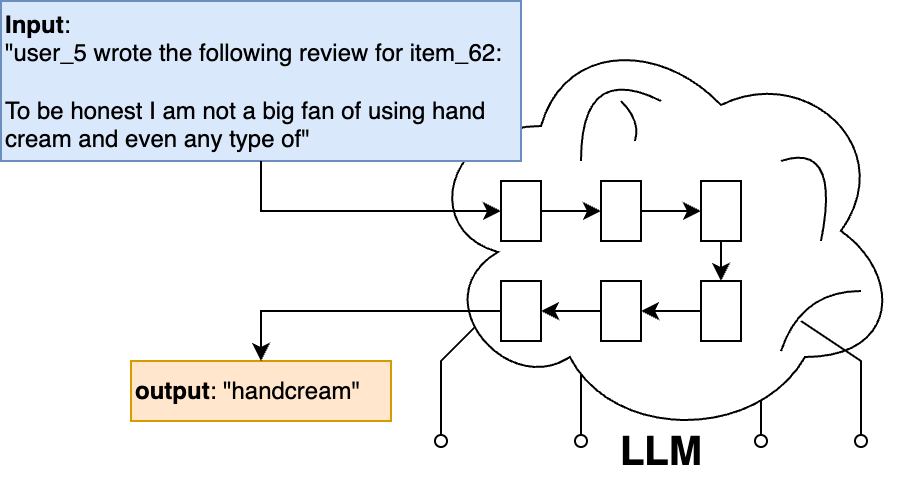
" width="400">

**Corresponding Code**:

The Pre-training scripts can be found in:
- `llm4rec_training.py`: This script handles the pretraining of the LLM on the recommendation data. It sets up the model, loads the data, and runs the training loop.

#### Step 4.2 - **Fine-Tuning Stage**

Different from the pretraining stage, the fine-tuning stage focuses on the actual recommendation task, so the optimization objective should be a more recommendation-oriented likelihood function. We define the recommendation probability that measures whether the LLM recommendations are statistically close to historical user purchase records:

<math display="block"><msub><mi>L</mi><mrow><mi>f</mi><mi>i</mi><mi>n</mi><mi>e</mi><mo>−</mo><mi>t</mi><mi>u</mi><mi>n</mi><mi>e</mi></mrow></msub><mo>=</mo><mo>−</mo><munderover><mo data-mjx-texclass="OP">∑</mo><mrow><mi>i</mi></mrow><mrow></mrow></munderover><mi>l</mi><mi>o</mi><mi>g</mi><mi>P</mi><mo stretchy="false">(</mo><msub><mi>S</mi><mi>i</mi></msub><mrow><mo stretchy="false">|</mo></mrow><mi>P</mi><msub><mi>r</mi><mi>i</mi></msub><mo>;</mo><mi>θ</mi><mo stretchy="false">)</mo></math>

where `Pr_i` is the prompt for fine-tuning stage, `S_i` is the final recommendation list, and `θ` denotes the LLM weights.

You can refer to the corresponding Python code for the fine-tuning logic. 


**Example**:

For example, in the fine-tuning process, since the input prompt would be more focuing on recommendation task, the input can be something like:
"user_5 has interacted with item_12, item_45, item_78, item_34, item_23, item_56, item_89, item_90, item_11, item_67. 
The user will interact with: "

And the model would output something like:
"item_5, item_20, item_33"
(The output is token by token actually.)

Based on the output and the ground truth, now the loss is calculated using more recommendation task methods, rather than in the pre-training stage, the loss is more NLP-oriented.

<img src="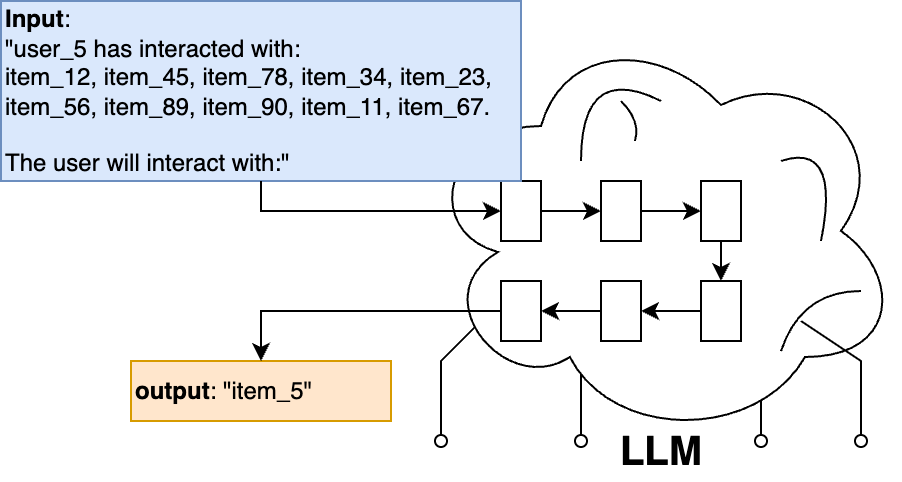
" width="400">

**Corresponding Code**:

The Fine-tuning scripts can be found in:
- `llm4rec_finetuning.py`: This script handles the fine-tuning of the LLM on the recommendation data. It sets up the model for fine-tuning, loads the pre-trained weights, and runs the fine-tuning loop with the recommendation-specific objective.

---

Through the two-stage process, the LLM is aligned with the recommendation task. 
Pretraining on the full user-item corpus gives it a strong foundation in understanding users, items, and their textual contexts in a unified way. 
Fine-tuning then hones the model’s ability to generate the right item recommendations when given a user’s prompt. 

In summary, the model first learns how to speak the language of the data, and then learns how to speak the language of recommendations. 
By the end of training, when you provide a prompt with a particular user ID and history, the LLM can effectively leverage both the collaborative signals and content knowledge it acquired to output likely items that the user will be interested in – fulfilling the goal of a generative recommender system.

---
### Discussion

#### Other Approaches to Integrating LLMs in Recommender Systems
LLM4Rec is one example of a growing family of methods that integrate LLMs into recommender systems. There are various approaches to adapting LLMs for recommendation tasks, each with its own strengths and weaknesses.
Broadly, other existing work in this space follows several directions:

- Prompt-based zero/few-shot approaches, where the LLM is kept frozen and clever prompt engineering is used to elicit recommendations without retraining.

- Feature-augmentation approaches, where the LLM generates additional descriptive or contextual features that are then used by a separate recommender.

- End-to-end fine-tuned approaches, such as LLM4Rec, that modify the model’s architecture or vocabulary to directly learn from collaborative and content data together.

- Hybrid models with graphs or retrieval, where LLMs are paired with external modules like GNNs, LoRA, or RAG for better scalability and structure awareness.

While these methods differ in complexity and cost, they share the goal of leveraging the LLM’s semantic understanding while still capturing user–item relationships effectively.

#### Limitations and Future Directions
- **Scalability**: LLMs are computationally intensive, making it challenging to deploy them in real-time recommendation scenarios with large user bases and item catalogs. This is the major reason why currently LLM-based recommenders are not widely used in industry.

- **Target**: Although we have seen many methods of adapting LLMs for recommendation, there is still one critical question: LLM is designed for NLP tasks, but recommendation is more likely a ranking task. Yes, they share some similarities, but is it really a good idea to totally rely on LLM for recommendation? In this notebook, LLM4Rec is a totally generative method. But maybe a more realistic way is to use LLM as feature generator, and then use a conventional ranking model to do the final ranking. We have seen some industry applications of this idea (e.g. NoteLLM by RedNote).

---
### Outlook

The use of LLMs in recommendation is still in its early stages but holds significant promise, especially for tasks requiring rich semantic context, cold-start handling, or explanation generation. 

Future progress will likely focus on improving scalability (handling millions of users/items), enhancing alignment with real-world ranking metrics, and combining structured reasoning over graphs with the LLM’s generative abilities. 

For students and researchers, this area offers an opportunity to work at the intersection of natural language processing, graph learning, and recommender systems—tackling open questions such as how to efficiently integrate large-scale interaction graphs into LLM reasoning while keeping the system fast, accurate, and adaptable.

---
### For Your Interests

If you are interested in exploring more about LLMs for recommendation systems, nothing beats a good survey paper:

[A Survey on Large Language Models for Recommendation](https://arxiv.org/pdf/2305.19860) by Wu Likang, Zhi Zheng, and others, 2024. [GitHub](https://github.com/WLiK/LLM4Rec-Awesome-Papers)

This paper provides a comprehensive summary of the current state-of-the-art methods, challenges, and future directions in this rapidly evolving field.

